# Phrase Detection MVP

Building a minimal bar-level phrase prediction pipeline for labeled hardstyle tracks. This notebook:

1. Converts phrase marker JSONs into bar-level annotations.
2. Extracts lightweight log-mel features per bar.
3. Trains and evaluates a simple MLP classifier with optional context.
4. Reports baseline metrics and highlights next steps.



## Setup & assumptions

- Use BPM + downbeat offsets from label JSONs (assumed perfect).
- Assume 4/4 time, 4 beats per bar; extend last marker label to track end.
- Bars without explicit markers inherit the last known phrase.
- Features: per-bar log-mel summary (mean + std) for a configurable sample rate.
- Context: optional ±N bars concatenated to each feature vector.



In [18]:
from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import librosa
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
AUDIO_DIR = DATA_DIR / "audio"
LABEL_DIR = DATA_DIR / "labels"

SR = 22050
N_MELS = 64
BEATS_PER_BAR = 4
CONTEXT_BARS = 8
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)



In [19]:
@dataclass
class PhraseMarker:
    phrase_id: str
    bar_count: int
    time: float


@dataclass
class TrackLabels:
    track_name: str
    file_name: str
    duration: float
    bpm: float
    downbeat_offset: float
    markers: List[PhraseMarker]


@dataclass
class BarSegment:
    track_name: str
    bar_index: int
    start_time: float
    end_time: float
    phrase_label: str


def load_track_labels(label_path: Path) -> TrackLabels:
    """Load a label JSON into a TrackLabels dataclass."""
    with label_path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    markers = sorted(
        (
            PhraseMarker(
                phrase_id=marker["phraseId"],
                bar_count=int(marker["barCount"]),
                time=float(marker["time"]),
            )
            for marker in payload.get("phraseMarkers", [])
        ),
        key=lambda m: m.bar_count,
    )

    return TrackLabels(
        track_name=label_path.stem.replace(".labels", ""),
        file_name=payload["fileName"],
        duration=float(payload["duration"]),
        bpm=float(payload["bpm"]),
        downbeat_offset=float(payload["downbeatOffset"]),
        markers=markers,
    )


def _bar_duration_seconds(track: TrackLabels, beats_per_bar: int = BEATS_PER_BAR) -> float:
    beat_duration = 60.0 / track.bpm
    return beat_duration * beats_per_bar


def _generate_bar_labels(track: TrackLabels, beats_per_bar: int = BEATS_PER_BAR) -> List[str]:
    """Return the phrase label for every bar in the track."""
    if not track.markers:
        raise ValueError(f"Track {track.track_name} has no phrase markers")

    bar_duration = _bar_duration_seconds(track, beats_per_bar)
    total_bars = int(np.ceil(max(track.duration - track.downbeat_offset, 0) / bar_duration))

    labels: List[str] = []
    marker_idx = 0
    current_label = track.markers[0].phrase_id

    for bar_idx in range(total_bars):
        next_idx = marker_idx + 1
        if next_idx < len(track.markers) and bar_idx >= track.markers[next_idx].bar_count:
            marker_idx = next_idx
            current_label = track.markers[marker_idx].phrase_id
        labels.append(current_label)

    return labels


def build_bar_segments(track: TrackLabels, beats_per_bar: int = BEATS_PER_BAR) -> List[BarSegment]:
    """Return bar-level segments with phrase labels and timing."""
    bar_labels = _generate_bar_labels(track, beats_per_bar)
    bar_duration = _bar_duration_seconds(track, beats_per_bar)

    segments: List[BarSegment] = []
    for bar_idx, label in enumerate(bar_labels):
        start_time = track.downbeat_offset + bar_idx * bar_duration
        end_time = min(start_time + bar_duration, track.duration)
        segments.append(
            BarSegment(
                track_name=track.track_name,
                bar_index=bar_idx,
                start_time=start_time,
                end_time=end_time,
                phrase_label=label,
            )
        )

    return segments



In [20]:
def _log_mel_summary(segment: np.ndarray, sr: int, n_mels: int = N_MELS) -> np.ndarray:
    """Return concatenated mean and std of a log-mel spectrogram for a segment."""
    if segment.size == 0 or np.allclose(segment, 0):
        return np.zeros(n_mels * 2, dtype=np.float32)

    mel = librosa.feature.melspectrogram(
        y=segment,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=n_mels,
        power=2.0,
    )
    log_mel = librosa.power_to_db(mel + 1e-9)
    return np.concatenate([log_mel.mean(axis=1), log_mel.std(axis=1)]).astype(np.float32)


def extract_track_features(
    track: TrackLabels,
    audio_dir: Path = AUDIO_DIR,
    sr: int = SR,
    beats_per_bar: int = BEATS_PER_BAR,
) -> Tuple[np.ndarray, List[str], List[BarSegment]]:
    """Compute per-bar features + labels for a single track."""
    audio_path = audio_dir / track.file_name
    if not audio_path.exists():
        raise FileNotFoundError(f"Missing audio file for {track.track_name}: {audio_path}")

    audio, _ = librosa.load(audio_path.as_posix(), sr=sr, mono=True)
    segments = build_bar_segments(track, beats_per_bar)

    features: List[np.ndarray] = []
    labels: List[str] = []
    valid_segments: List[BarSegment] = []
    for seg in segments:
        start_sample = int(seg.start_time * sr)
        end_sample = min(int(seg.end_time * sr), audio.shape[0])
        if start_sample >= audio.shape[0]:
            break
        if end_sample <= start_sample:
            end_sample = min(start_sample + 512, audio.shape[0])
        segment_audio = audio[start_sample:end_sample]
        features.append(_log_mel_summary(segment_audio, sr))
        labels.append(seg.phrase_label)
        valid_segments.append(seg)

    return np.vstack(features), labels, valid_segments



In [21]:
def _with_context(features: np.ndarray, context: int) -> np.ndarray:
    """Concatenate ±context bars for each bar."""
    if context <= 0:
        return features

    pad = np.zeros((context, features.shape[1]), dtype=features.dtype)
    padded = np.vstack([pad, features, pad])
    window_size = context * 2 + 1
    contextualized = []
    for idx in range(features.shape[0]):
        window = padded[idx : idx + window_size]
        contextualized.append(window.reshape(-1))
    return np.vstack(contextualized)


def build_bar_dataset(
    label_dir: Path = LABEL_DIR,
    audio_dir: Path = AUDIO_DIR,
    sr: int = SR,
    beats_per_bar: int = BEATS_PER_BAR,
    context_bars: int = CONTEXT_BARS,
) -> pd.DataFrame:
    """Iterate through labeled tracks and assemble a feature table."""
    records: List[Dict] = []
    label_paths = sorted(label_dir.glob("*.labels.json"))

    for label_path in label_paths:
        track = load_track_labels(label_path)
        track_features, track_labels, segments = extract_track_features(
            track,
            audio_dir=audio_dir,
            sr=sr,
            beats_per_bar=beats_per_bar,
        )
        contextual_features = _with_context(track_features, context=context_bars)

        for feat_vec, label, seg in zip(contextual_features, track_labels, segments):
            records.append(
                {
                    "track": track.track_name,
                    "bar_index": seg.bar_index,
                    "start_time": seg.start_time,
                    "end_time": seg.end_time,
                    "label": label,
                    "feature": feat_vec,
                }
            )

    df = pd.DataFrame.from_records(records)
    return df



In [22]:
bar_df = build_bar_dataset()
print(f"Loaded {len(bar_df)} bars from {bar_df['track'].nunique()} tracks")
feature_dim = len(bar_df.iloc[0]["feature"]) if not bar_df.empty else 0
print(f"Feature dimension (incl. context): {feature_dim}")

label_counts = bar_df["label"].value_counts().sort_values(ascending=False)
display(label_counts.to_frame(name="count"))
bar_df.head()



C:\Users\mplx3\AppData\Local\Temp\ipykernel_23448\2634294927.py:29: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(audio_path.as_posix(), sr=sr, mono=True)
c:\Users\mplx3\Documents\GitHub\meow\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
c:\Users\mplx3\Documents\GitHub\meow\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=6
  warnings.warn(
c:\Users\mplx3\Documents\GitHub\meow\.venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=585
  warnings.warn(


Loaded 2530 bars from 19 tracks
Feature dimension (incl. context): 2176


,count
label,
bridge,1034
quiet,886
drop,253
lead,178
verse,90
buildUp,89


,track,bar_index,start_time,end_time,label,feature
0,Angels & Demons,0,1.677828,3.277828,quiet,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Angels & Demons,1,3.277828,4.877828,quiet,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Angels & Demons,2,4.877828,6.477828,quiet,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Angels & Demons,3,6.477828,8.077828,quiet,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Angels & Demons,4,8.077828,9.677828,quiet,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [23]:
tracks = sorted(bar_df["track"].unique())
train_tracks, val_tracks = train_test_split(
    tracks, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)
train_df = bar_df[bar_df["track"].isin(train_tracks)].reset_index(drop=True)
val_df = bar_df[bar_df["track"].isin(val_tracks)].reset_index(drop=True)

print(
    f"Train bars: {len(train_df)} across {len(train_tracks)} tracks | "
    f"Val bars: {len(val_df)} across {len(val_tracks)} tracks"
)



Train bars: 1998 across 15 tracks | Val bars: 532 across 4 tracks


In [24]:
def df_to_arrays(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    X = np.stack(df["feature"].to_list())
    y = df["label"].to_numpy()
    return X, y


label_encoder = LabelEncoder().fit(bar_df["label"])
X_train, y_train = df_to_arrays(train_df)
X_val, y_val = df_to_arrays(val_df)
y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)

num_classes = len(label_encoder.classes_)
print(f"Classes ({num_classes}): {label_encoder.classes_}")



Classes (6): ['bridge' 'buildUp' 'drop' 'lead' 'quiet' 'verse']


In [25]:
def train_mlp_classifier(
    X: np.ndarray,
    y: np.ndarray,
    hidden_layers: Tuple[int, ...] = (256, 128),
    random_state: int = RANDOM_STATE,
) -> MLPClassifier:
    sample_weights = compute_sample_weight(class_weight="balanced", y=y)
    clf = MLPClassifier(    
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        random_state=random_state,
        verbose=False,
    )
    clf.fit(X, y, sample_weight=sample_weights)
    return clf


def evaluate_split(
    model: MLPClassifier,
    X: np.ndarray,
    y_true: np.ndarray,
    split_name: str,
) -> Dict[str, np.ndarray]:
    y_pred = model.predict(X)
    print(f"\n=== {split_name} ===")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0,
        )
    )

    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        cmap="viridis",
    )
    plt.title(f"{split_name} normalized confusion matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

    return {"y_pred": y_pred}




=== Train ===
              precision    recall  f1-score   support

      bridge       0.97      0.83      0.89       840
     buildUp       0.95      0.97      0.96        71
        drop       0.88      0.93      0.90       213
        lead       0.74      0.98      0.85       131
       quiet       0.87      0.94      0.91       681
       verse       0.85      0.94      0.89        62

    accuracy                           0.90      1998
   macro avg       0.88      0.93      0.90      1998
weighted avg       0.91      0.90      0.90      1998



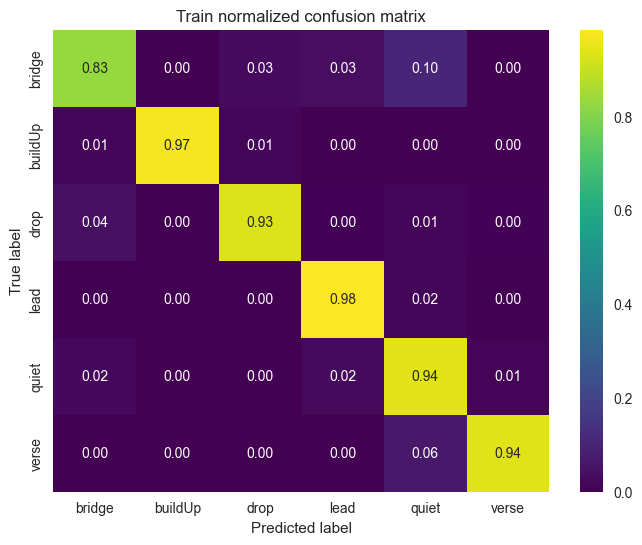


=== Validation ===
              precision    recall  f1-score   support

      bridge       0.61      0.69      0.64       194
     buildUp       0.60      0.67      0.63        18
        drop       0.59      0.50      0.54        40
        lead       0.55      0.62      0.58        47
       quiet       0.79      0.73      0.76       205
       verse       0.12      0.07      0.09        28

    accuracy                           0.65       532
   macro avg       0.54      0.54      0.54       532
weighted avg       0.64      0.65      0.64       532



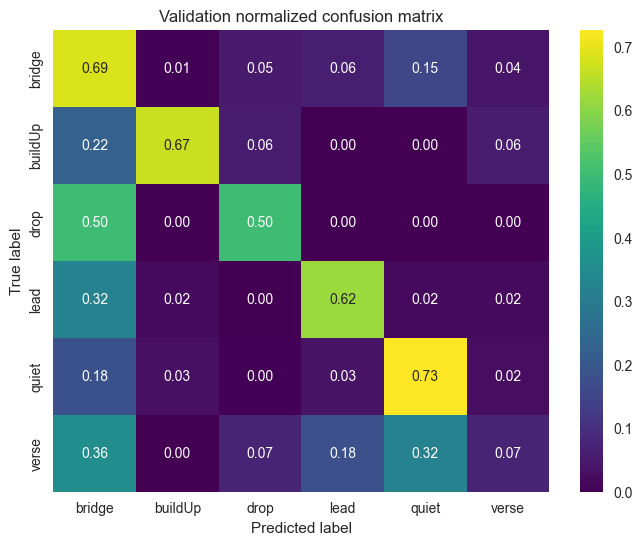

In [26]:
mlp_model = train_mlp_classifier(X_train, y_train_enc)
train_results = evaluate_split(mlp_model, X_train, y_train_enc, "Train")
val_results = evaluate_split(mlp_model, X_val, y_val_enc, "Validation")



In [27]:
def attach_predictions(df: pd.DataFrame, pred_indices: np.ndarray) -> pd.DataFrame:
    decoded = label_encoder.inverse_transform(pred_indices)
    enriched = df.copy()
    enriched["pred"] = decoded
    enriched["correct"] = enriched["pred"] == enriched["label"]
    return enriched


val_with_preds = attach_predictions(val_df, val_results["y_pred"])
val_accuracy_by_phrase = (
    val_with_preds.groupby("label")["correct"].mean().sort_values(ascending=False)
)
val_accuracy_by_track = (
    val_with_preds.groupby("track")["correct"].mean().sort_values(ascending=False)
)

print("Per-label validation accuracy:")
display(val_accuracy_by_phrase.to_frame(name="val_accuracy"))

print("Per-track validation accuracy:")
display(val_accuracy_by_track.to_frame(name="val_accuracy"))



Per-label validation accuracy:


,val_accuracy
label,
quiet,0.726829
bridge,0.685567
buildUp,0.666667
lead,0.617021
drop,0.500000
verse,0.071429


Per-track validation accuracy:


,val_accuracy
track,
Darkest Hour (The Clock),0.760000
ASCENSION,0.631206
GHOST,0.612403
Angels & Demons,0.562500


## Next steps

- Swap in richer context (e.g., ±2 bars) or sequential models (GRU/TCN) using the same feature table.
- Experiment with alternative features (MFCC deltas, chroma, spectral contrast) or pretrained embeddings.
- Add data augmentation (pitch/time shifts) or semi-supervised pseudo-labeling to bolster small data.
- Evaluate with track-level cross-validation to reduce variance and detect overfitting.
- Persist datasets / trained weights so they can be reused without recomputing audio features.

